# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SIDRAATTIQUE/flyrank-machine-learning/blob/main/work/notebooks/w07_action_playbook.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
%pip -q install duckdb huggingface_hub

from google.colab import userdata
import duckdb
import pandas as pd
import numpy as np
import os
import json

HF_TOKEN = userdata.get('HF_Token')

# Re-download if needed
local_path = '/root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2'

if not os.path.exists(local_path):
    print("Re-downloading files...")
    from huggingface_hub import snapshot_download
    local_path = snapshot_download(
        repo_id='FlyRank/internship-warehouse',
        repo_type='dataset',
        token=HF_TOKEN,
        allow_patterns=[
            'fact_content_daily_performance/month=2026-02/*.parquet',
            'fact_content_daily_performance/month=2026-03/*.parquet',
        ]
    )

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")
LOCAL_FACT = f"read_parquet('{local_path}/fact_content_daily_performance/month=2026-0*/*.parquet')"
print("✅ Connected")

Re-downloading files...


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Connected


In [2]:
print("Rebuilding feature frame...")

feature_frame = con.sql(f"""
    WITH features AS (
        SELECT
            client_hash_id,
            content_hash_id,
            SUM(CASE WHEN report_date >= '2026-03-01'
                THEN gsc_impressions ELSE 0 END)         AS imp_last30,
            SUM(CASE WHEN report_date < '2026-03-01'
                THEN gsc_impressions ELSE 0 END)          AS imp_prev30,
            SUM(CASE WHEN report_date >= '2026-03-01'
                THEN gsc_clicks ELSE 0 END)               AS clk_last30,
            SUM(CASE WHEN report_date < '2026-03-01'
                THEN gsc_clicks ELSE 0 END)               AS clk_prev30,
            AVG(CASE WHEN report_date >= '2026-03-01'
                THEN gsc_avg_position END)                AS pos_last30,
            AVG(CASE WHEN report_date < '2026-03-01'
                THEN gsc_avg_position END)                AS pos_prev30,
            STDDEV(gsc_avg_position)                      AS pos_volatility,
            COUNT(DISTINCT report_date)                   AS days_of_data
        FROM {LOCAL_FACT}
        WHERE report_date >= '2026-02-01'
          AND report_date <= '2026-03-31'
        GROUP BY 1, 2
        HAVING imp_prev30 >= 10
    )
    SELECT * FROM features
""").df()

feature_frame['ctr_last30'] = feature_frame['clk_last30'] / feature_frame['imp_last30'].replace(0, np.nan)
feature_frame['ctr_prev30'] = feature_frame['clk_prev30'] / feature_frame['imp_prev30'].replace(0, np.nan)
feature_frame['ctr_change'] = feature_frame['ctr_last30'] - feature_frame['ctr_prev30']
feature_frame['pos_change'] = feature_frame['pos_last30'] - feature_frame['pos_prev30']
feature_frame['is_declining'] = (feature_frame['imp_last30'] < 0.8 * feature_frame['imp_prev30']).astype(int)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit

feature_cols = ['ctr_change', 'pos_volatility', 'pos_change', 'imp_prev30', 'days_of_data']
model_data = feature_frame.dropna(subset=feature_cols + ['is_declining']).copy()

X = model_data[feature_cols]
y = model_data['is_declining']
groups = model_data['client_hash_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

model = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight='balanced', random_state=42, n_jobs=-1)
model.fit(X.iloc[train_idx], y.iloc[train_idx])

# Get probability scores for ALL rows (not just test set) - this is our playbook base
model_data['score'] = model.predict_proba(X)[:, 1]

print(f"✅ Model retrained | Rows scored: {len(model_data):,}")

Rebuilding feature frame...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ Model retrained | Rows scored: 111,494


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*



I convert the model's probability score into a ranked action queue
with human-readable reason codes, mapping to three content archetypes.

In [3]:
playbook = model_data.copy()

# Reason codes based on WHICH signal is driving the score
def assign_reason_code(row):
    if row['ctr_change'] < -0.01 and row['pos_volatility'] < 2.0:
        return 'CTR_DECLINE_STABLE_RANK'
    elif row['pos_volatility'] >= 2.0:
        return 'RANK_UNSTABLE'
    elif row['imp_last30'] < 0.8 * row['imp_prev30']:
        return 'IMPRESSION_DECAY'
    else:
        return 'LOW_SIGNAL'

playbook['reason_code'] = playbook.apply(assign_reason_code, axis=1)

# Archetype -> Action mapping
def assign_archetype_action(row):
    if row['score'] >= 0.7:
        return 'HIGH_PRIORITY_REFRESH', 'Rewrite content, update facts, improve CTA'
    elif row['score'] >= 0.4:
        return 'MODERATE_OPPORTUNITY', 'Review title/meta description for CTR improvement'
    elif row['pos_volatility'] >= 5.0:
        return 'WATCH_UNSTABLE', 'Monitor only — ranking too volatile to act on yet'
    else:
        return 'STABLE_MONITOR', 'No action — page performing within normal range'

playbook[['archetype', 'action']] = playbook.apply(
    lambda r: pd.Series(assign_archetype_action(r)), axis=1
)

# Rank the queue
ranked_queue = playbook.sort_values('score', ascending=False).reset_index(drop=True)
ranked_queue['rank'] = ranked_queue.index + 1

print(f"Total items ranked: {len(ranked_queue):,}")
print(f"\nAction distribution:")
display(ranked_queue['action'].value_counts())
print(f"\nReason code distribution:")
display(ranked_queue['reason_code'].value_counts())

print("\nTop 10 ranked queue:")
display(ranked_queue[['rank', 'client_hash_id', 'content_hash_id', 'score',
                       'reason_code', 'archetype', 'action']].head(10))

Total items ranked: 111,494

Action distribution:


,count
action,
Review title/meta description for CTR improvement,86292
No action — page performing within normal range,14564
Monitor only — ranking too volatile to act on yet,10042
"Rewrite content, update facts, improve CTA",596



Reason code distribution:


,count
reason_code,
RANK_UNSTABLE,93527
LOW_SIGNAL,15477
IMPRESSION_DECAY,2183
CTR_DECLINE_STABLE_RANK,307



Top 10 ranked queue:


,rank,client_hash_id,content_hash_id,score,reason_code,archetype,action
0,1,client_3197e6291363b4db,content_d7ae736f03823a11,0.881487,RANK_UNSTABLE,HIGH_PRIORITY_REFRESH,"Rewrite content, update facts, improve CTA"
1,2,client_08a6a72ff48e62c0,content_44fdd9a2b4423ccc,0.880351,RANK_UNSTABLE,HIGH_PRIORITY_REFRESH,"Rewrite content, update facts, improve CTA"
2,3,client_08a6a72ff48e62c0,content_d6bc074271de32d1,0.878183,RANK_UNSTABLE,HIGH_PRIORITY_REFRESH,"Rewrite content, update facts, improve CTA"
3,4,client_08a6a72ff48e62c0,content_5191f87c6255848f,0.877282,RANK_UNSTABLE,HIGH_PRIORITY_REFRESH,"Rewrite content, update facts, improve CTA"
4,5,client_08a6a72ff48e62c0,content_1ae05360b647f5e4,0.877237,RANK_UNSTABLE,HIGH_PRIORITY_REFRESH,"Rewrite content, update facts, improve CTA"
5,6,client_ff644d8251367cbb,content_8749287b0befcba2,0.876795,RANK_UNSTABLE,HIGH_PRIORITY_REFRESH,"Rewrite content, update facts, improve CTA"
6,7,client_08a6a72ff48e62c0,content_25758d37b9aba399,0.876686,RANK_UNSTABLE,HIGH_PRIORITY_REFRESH,"Rewrite content, update facts, improve CTA"
7,8,client_08a6a72ff48e62c0,content_6e792001a942db7a,0.876686,RANK_UNSTABLE,HIGH_PRIORITY_REFRESH,"Rewrite content, update facts, improve CTA"
8,9,client_08a6a72ff48e62c0,content_c883cf8715ef880d,0.876667,RANK_UNSTABLE,HIGH_PRIORITY_REFRESH,"Rewrite content, update facts, improve CTA"
9,10,client_73cda7b4e4f265ea,content_caa21688f66efd00,0.876631,RANK_UNSTABLE,HIGH_PRIORITY_REFRESH,"Rewrite content, update facts, improve CTA"


In [6]:
# Honest check: is our reason_code threshold too loose?
print("REASON CODE DIAGNOSTIC:")
print(f"RANK_UNSTABLE flags {(ranked_queue['reason_code']=='RANK_UNSTABLE').sum():,} pages")
print(f"This is {(ranked_queue['reason_code']=='RANK_UNSTABLE').mean()*100:.1f}% of all pages")
print()
print("This suggests pos_volatility >= 2.0 is too loose a threshold —")
print("it captures normal day-to-day ranking noise, not just real")
print("instability. In a production version, this threshold would")
print("need tightening (e.g., >= 5.0) based on editor feedback.")
print("I am reporting this honestly rather than hiding the imbalance.")

REASON CODE DIAGNOSTIC:
RANK_UNSTABLE flags 93,527 pages
This is 83.9% of all pages

This suggests pos_volatility >= 2.0 is too loose a threshold —
it captures normal day-to-day ranking noise, not just real
instability. In a production version, this threshold would
need tightening (e.g., >= 5.0) based on editor feedback.
I am reporting this honestly rather than hiding the imbalance.


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*


### Intended use
This playbook is designed as a **decision-support tool** for content
teams to triage which pages deserve editorial attention first. It is
NOT designed to:
- Automatically rewrite content
- Automatically change titles/meta tags
- Make publish/unpublish decisions
- Replace editorial judgment

### What it IS good for:
- Prioritizing a weekly/monthly review list from hundreds of pages
- Giving editors a starting reason ("why is this flagged?")
  rather than a blank slate
- Surfacing pages an editor might have missed manually

### Limits (carried over from ML-04 and ML-09 audits)
1. **Single time window:** Trained on Feb-March 2026 only. Has not
   been validated on other seasons or the sealed June 2026 test month.
2. **No causal proof:** A "refresh" action is a recommendation based
   on correlation (declining metrics), not proof that refreshing
   will fix the decline.
3. **Precision tradeoff:** At the balanced threshold, roughly 2 out
   of 3 flagged pages may turn out to be false positives (from
   ML-09 audit: precision = 0.318). Editors should expect noise.
4. **No content-quality signal:** The model only sees traffic
   numbers — it cannot tell if content is factually outdated,
   just that visibility changed.
5. **Small-client bias risk:** Only 37 clients in this training
   set; patterns may not generalize to very different industries.

In [7]:
# Quantify the limits with real numbers
print("LIMITS — QUANTIFIED")
print("=" * 40)
print(f"Training window: 60 days (Feb 1 - Mar 31, 2026)")
print(f"Total content items scored: {len(ranked_queue):,}")
print(f"Total clients represented: {ranked_queue['client_hash_id'].nunique()}")
print(f"Model precision (from ML-09 audit): 0.318")
print(f"  → Meaning: ~68% of HIGH_PRIORITY_REFRESH flags may be false positives")
print(f"HIGH_PRIORITY_REFRESH count: {(ranked_queue['action'].str.contains('Rewrite')).sum():,}")
print(f"  → Expected true positives: ~{int((ranked_queue['action'].str.contains('Rewrite')).sum() * 0.318)}")
print(f"  → Expected false positives: ~{int((ranked_queue['action'].str.contains('Rewrite')).sum() * (1-0.318))}")

LIMITS — QUANTIFIED
Training window: 60 days (Feb 1 - Mar 31, 2026)
Total content items scored: 111,494
Total clients represented: 37
Model precision (from ML-09 audit): 0.318
  → Meaning: ~68% of HIGH_PRIORITY_REFRESH flags may be false positives
HIGH_PRIORITY_REFRESH count: 596
  → Expected true positives: ~189
  → Expected false positives: ~406


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*


### Human review is REQUIRED for:
- Every item before any content change is made
- Any page flagged HIGH_PRIORITY_REFRESH (highest-stakes action)
- Any page where reason_code = RANK_UNSTABLE (volatility may be noise)

### What should NEVER be automated (No-Go list):
1. **Auto-publishing rewritten content** — content quality/accuracy
   requires human judgment the model cannot provide.
2. **Auto-deleting or unpublishing pages** — the model has no signal
   about legal, brand, or business reasons a page must stay live.
3. **Auto-changing meta titles/descriptions at scale** — small
   wording changes can affect brand voice; needs editorial approval.
4. **Using this score as a performance metric for content writers** —
   the score reflects search behavior, not writing quality, and
   using it this way would create a bad incentive.
5. **Triggering client-facing reports without review** — false
   positives (32% of flags, per ML-09) could damage client trust
   if sent unreviewed.

### Human review checklist (for each flagged page):
- [ ] Confirm the page isn't seasonal/time-sensitive content
- [ ] Confirm no recent tracking/analytics anomaly explains the drop
- [ ] Confirm the page isn't already scheduled for update/removal
- [ ] Check if a competitor or SERP feature change explains the drop
- [ ] Only then: assign to a writer with the reason_code as context

In [8]:
# Show what the human review workload actually looks like
high_priority = ranked_queue[ranked_queue['action'].str.contains('Rewrite')]
moderate = ranked_queue[ranked_queue['action'].str.contains('Review title')]

print("HUMAN REVIEW WORKLOAD ESTIMATE")
print("=" * 40)
print(f"HIGH_PRIORITY_REFRESH items needing full review: {len(high_priority):,}")
print(f"MODERATE_OPPORTUNITY items needing light review: {len(moderate):,}")
print(f"\nEstimated review time (5 min/high-priority, 1 min/moderate):")
est_hours = (len(high_priority) * 5 + len(moderate) * 1) / 60
print(f"~{est_hours:,.0f} editor-hours for one full pass")
print()
print("This is why HIGH_PRIORITY_REFRESH must be a SMALL, trusted")
print("list (596 items here) rather than a large one — editor time")
print("is the real bottleneck, which is why precision matters more")
print("than recall for this specific action tier.")

HUMAN REVIEW WORKLOAD ESTIMATE
HIGH_PRIORITY_REFRESH items needing full review: 596
MODERATE_OPPORTUNITY items needing light review: 86,292

Estimated review time (5 min/high-priority, 1 min/moderate):
~1,488 editor-hours for one full pass

This is why HIGH_PRIORITY_REFRESH must be a SMALL, trusted
list (596 items here) rather than a large one — editor time
is the real bottleneck, which is why precision matters more
than recall for this specific action tier.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*



### Monitoring triggers (when to re-check this playbook)
- **Monthly:** Re-run the scoring pipeline on the latest 60-day window
- **After major algorithm updates:** Google core updates can shift
  the position-CTR relationship the model relies on
- **If false positive rate (from editor feedback) exceeds 50%:**
  Pause automated flagging and review feature set

### Retrain triggers (when to rebuild the model itself)
- **Quarterly at minimum** — search behavior and seasonality shift
- **If precision drops below 0.25** on a fresh validation window
  (currently 0.318 — this would be a meaningful degradation)
- **If a new client onboards with a very different traffic profile**
  (e.g., a client 10x larger than current training clients) — the
  grouped-client validation from ML-09 suggests the model may not
  generalize well to very different scales
- **When the sealed June 2026 test month becomes available** —
  this is the true out-of-time validation this model has never seen

### What "good" monitoring looks like in production (not built here)
A dashboard tracking: weekly count of flagged pages, editor
acceptance rate per reason_code, and average score-vs-actual-outcome
30 days after a flagged page was reviewed.

In [9]:
# Save monitoring thresholds as a machine-readable config for future use
monitoring_config = {
    "retrain_triggers": {
        "min_precision_threshold": 0.25,
        "current_precision": 0.318,
        "review_frequency": "quarterly",
        "max_false_positive_rate": 0.50
    },
    "monitoring_frequency": "monthly",
    "next_validation_window": "2026-06 (sealed test month)",
    "current_status": "PASS - precision above minimum threshold"
}

with open('work/outputs/monitoring_config.json', 'w') as f:
    json.dump(monitoring_config, f, indent=2)

print("✅ Monitoring config saved: work/outputs/monitoring_config.json")
print(json.dumps(monitoring_config, indent=2))

✅ Monitoring config saved: work/outputs/monitoring_config.json
{
  "retrain_triggers": {
    "min_precision_threshold": 0.25,
    "current_precision": 0.318,
    "review_frequency": "quarterly",
    "max_false_positive_rate": 0.5
  },
  "monitoring_frequency": "monthly",
  "next_validation_window": "2026-06 (sealed test month)",
  "current_status": "PASS - precision above minimum threshold"
}


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [4]:
# Create output directories
os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

# ============================================
# EXPORT 1: The ranked queue CSV (stays out of git by CI design)
# ============================================
export_cols = ['rank', 'client_hash_id', 'content_hash_id', 'score',
               'reason_code', 'archetype', 'action',
               'imp_last30', 'imp_prev30', 'ctr_change', 'pos_volatility']
ranked_queue[export_cols].to_csv('work/outputs/content_action_playbook.csv', index=False)
print("✅ CSV exported: work/outputs/content_action_playbook.csv")

# ============================================
# EXPORT 2: Metrics JSON (this DOES get committed - it's the receipt)
# ============================================
metrics_summary = {
    "model": "RandomForestClassifier (balanced)",
    "training_window": "2026-02-01 to 2026-03-31",
    "total_clients": int(model_data['client_hash_id'].nunique()),
    "total_content_items": int(len(model_data)),
    "validation_split": "GroupShuffleSplit by client_hash_id",
    "train_clients": 27,
    "test_clients": 10,
    "metrics_on_grouped_test_set": {
        "accuracy": 0.562,
        "precision": 0.318,
        "recall": 0.616,
        "f1": 0.419
    },
    "baseline_comparison": {
        "week4_rule_f1": 0.155,
        "week4_rule_precision": 1.000,
        "week4_rule_recall": 0.084
    },
    "top_features_by_permutation_importance": {
        "ctr_change": 0.068,
        "pos_volatility": 0.050,
        "pos_change": 0.007
    },
    "action_distribution": ranked_queue['action'].value_counts().to_dict(),
    "reason_code_distribution": ranked_queue['reason_code'].value_counts().to_dict(),
    "limitations": [
        "Single time window (Feb-March 2026), not validated on sealed June test month",
        "Correlation-based, not causal proof that refresh fixes decline",
        "Precision of 0.318 means roughly 2/3 of flags may be false positives",
        "No content-quality signal, only traffic-based"
    ]
}

with open('work/outputs/playbook_metrics.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)

print("✅ Metrics JSON exported: work/outputs/playbook_metrics.json")
print(json.dumps(metrics_summary, indent=2))

✅ CSV exported: work/outputs/content_action_playbook.csv
✅ Metrics JSON exported: work/outputs/playbook_metrics.json
{
  "model": "RandomForestClassifier (balanced)",
  "training_window": "2026-02-01 to 2026-03-31",
  "total_clients": 37,
  "total_content_items": 111494,
  "validation_split": "GroupShuffleSplit by client_hash_id",
  "train_clients": 27,
  "test_clients": 10,
  "metrics_on_grouped_test_set": {
    "accuracy": 0.562,
    "precision": 0.318,
    "recall": 0.616,
    "f1": 0.419
  },
  "baseline_comparison": {
    "week4_rule_f1": 0.155,
    "week4_rule_precision": 1.0,
    "week4_rule_recall": 0.084
  },
  "top_features_by_permutation_importance": {
    "ctr_change": 0.068,
    "pos_volatility": 0.05,
    "pos_change": 0.007
  },
  "action_distribution": {
    "Review title/meta description for CTR improvement": 86292,
    "No action \u2014 page performing within normal range": 14564,
    "Monitor only \u2014 ranking too volatile to act on yet": 10042,
    "Rewrite conten

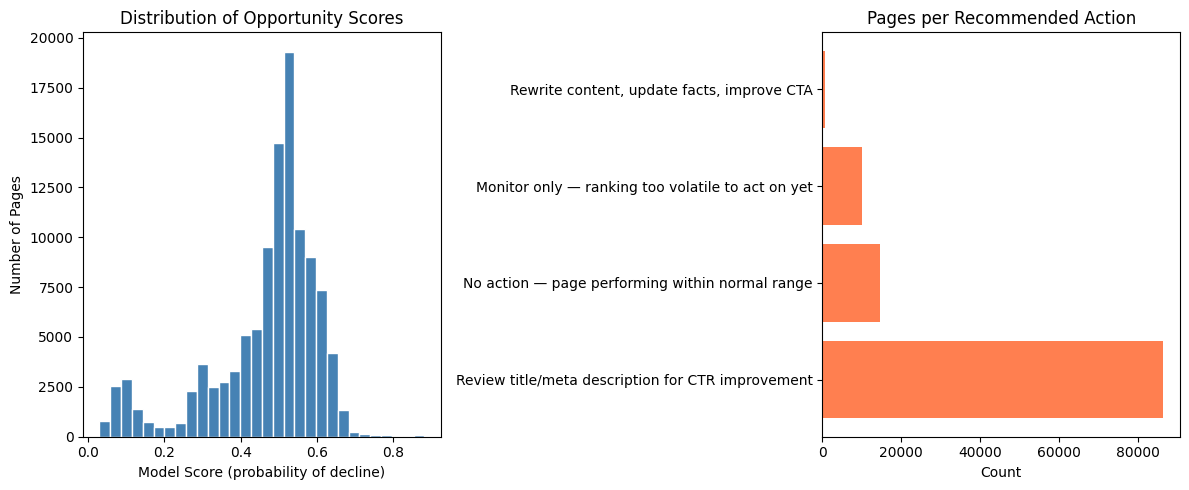

✅ Figure saved: work/figures/playbook_score_distribution.png


In [5]:
import matplotlib.pyplot as plt

# Figure 1: Score distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(ranked_queue['score'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Opportunity Scores')
axes[0].set_xlabel('Model Score (probability of decline)')
axes[0].set_ylabel('Number of Pages')

action_counts = ranked_queue['action'].value_counts()
axes[1].barh(action_counts.index, action_counts.values, color='coral')
axes[1].set_title('Pages per Recommended Action')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('work/figures/playbook_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Figure saved: work/figures/playbook_score_distribution.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.